# Notebook 7 — Extend the dataset to $N = 10^{12}$

**Purpose.** The audit fit (notebooks 05, 06) used $N \in [10^5, 10^{11}]$ and yielded:

| | buggy v14 | corrected (audit) |
|---|---:|---:|
| n dataset points | 111 | 110 |
| $a$ (coefficient on $\sqrt{\omega(g)}$) | +1.238 | +0.899 |
| $\Delta\mathrm{AIC}(M_1 - M_2)$ | −104 | −42 |
| median $R^2_{CV}$ | 0.75 | 0.92 |
| $a$ 90% CI | — | [0.832, 0.969] |

Before submission we extend to $N = 10^{12}$ (which matches the ambition in `manual-pb.md` and adds ~10 new rows to the fit). This notebook:

1. Runs the C sieve at the two new points ($3 \cdot 10^{11}$, $10^{12}$); histograms at lower $N$ are reused from `ml_data/`.
2. Rebuilds the corrected dataset on the expanded range.
3. Refits $M_0$–$M_4$.
4. Reruns bootstrap (B = 1000) for 90% CI on $a, b, c$.
5. Side-by-side comparison: audit range vs extended range.

**Runtime.** Sieve at $3 \cdot 10^{11} \approx 70$ s, at $10^{12} \approx 240$ s → total ~5 min for the new points. Fits + bootstrap: seconds.

**Outcomes we want to see:**
- Coefficients stable (within one audit-CI): confirms signal is robust.
- CI tightens: validates that the small-dataset warning in limitations is the binding concern.
- $R^2_{CV}$ on held-out $10^{12}$ is comparable to audit values: confirms convergence.
- $\Delta\mathrm{AIC}(M_1 - M_2)$ moves further from 0 in the same direction: strengthens the headline claim.

In [1]:
import sys, os, time, math, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import integrate, optimize
import matplotlib.pyplot as plt

NB_DIR   = Path.cwd()
C_BIN    = NB_DIR / 'main-csv-static'
DATA_DIR = NB_DIR / 'ml_data'
DATA_DIR.mkdir(exist_ok=True)

C2_TWIN = 0.6601618158468695739278121100145557784326233602847334133194484233354

def hl_correct(g):
    if g <= 0 or g % 2: return 0.0
    n = g
    while n % 2 == 0: n //= 2
    corr, p = 1.0, 3
    while p*p <= n:
        if n % p == 0:
            corr *= (p-1)/(p-2)
            while n % p == 0: n //= p
        p += 2
    if n > 1: corr *= (n-1)/(n-2)
    return 2*C2_TWIN*corr

def omega(n):
    if n <= 1: return 0
    c, d = 0, 2
    while d*d <= n:
        if n % d == 0:
            c += 1
            while n % d == 0: n //= d
        d += 1
    if n > 1: c += 1
    return c

def li2(N):
    v, _ = integrate.quad(lambda t: 1.0/np.log(t)**2, 2.0, N, limit=200)
    return float(v)

## 1. Generate / load histograms up to $10^{12}$

Reuses any CSV already present in `ml_data/`. The two new values trigger fresh C-sieve runs.

In [2]:
def run_c(N):
    csv = DATA_DIR / f'gaps_N{int(N)}.csv'
    if csv.exists():
        return pd.read_csv(csv), 'cached'
    run_dir = DATA_DIR / f'run_{int(N)}'
    run_dir.mkdir(exist_ok=True)
    t0 = time.perf_counter()
    subprocess.run([str(C_BIN), str(int(N)), '0'], cwd=run_dir,
                   check=True, capture_output=True, text=True)
    df = pd.read_csv(run_dir / 'gaps.csv')
    df.to_csv(csv, index=False)
    for f in ['gaps.csv', 'records.csv']:
        (run_dir / f).unlink(missing_ok=True)
    run_dir.rmdir()
    return df, f'{time.perf_counter()-t0:.1f}s'

# Audit range (identical to notebook 05) + two extension points
AUDIT_N  = sorted(set([int(x) for x in np.geomspace(1e5, 1e10, 18)] +
                      [int(3e10), int(7e10), int(1e11)]))
EXTEND_N = [int(3e11), int(1e12), int(3e12), int(1e13)]
N_VALUES = AUDIT_N + EXTEND_N

EXTEND_N = [int(3e11), int(1e12), int(3e12), int(1e13)]
histograms = {}
t0 = time.perf_counter()
for N in N_VALUES:
    df, how = run_c(N)
    histograms[N] = df
    print(f'  N={N:>.1e}  {how:>10s}  {len(df)} rows')
print(f'total wall clock: {time.perf_counter()-t0:.1f} s')

  N=1.0e+05      cached  34 rows
  N=2.0e+05      cached  39 rows
  N=3.9e+05      cached  43 rows
  N=7.6e+05      cached  51 rows
  N=1.5e+06      cached  59 rows
  N=3.0e+06      cached  63 rows
  N=5.8e+06      cached  68 rows
  N=1.1e+07      cached  76 rows
  N=2.3e+07      cached  82 rows
  N=4.4e+07      cached  90 rows
  N=8.7e+07      cached  97 rows
  N=1.7e+08      cached  105 rows
  N=3.4e+08      cached  114 rows
  N=6.7e+08      cached  126 rows
  N=1.3e+09      cached  133 rows
  N=2.6e+09      cached  147 rows
  N=5.1e+09      cached  155 rows
  N=1.0e+10      cached  167 rows
  N=3.0e+10      cached  189 rows
  N=7.0e+10      cached  206 rows
  N=1.0e+11      cached  209 rows
  N=3.0e+11      cached  231 rows
  N=1.0e+12      cached  255 rows
  N=3.0e+12      cached  281 rows
  N=1.0e+13      cached  310 rows
total wall clock: 0.0 s


## 2. Build the corrected dataset on the extended range

In [3]:
RHO_MIN, RHO_MAX = 0.05, 1.10

def build_dataset(Ns):
    rows = []
    for N in Ns:
        df = histograms[N]
        lnN, lnlnN = math.log(N), math.log(math.log(N))
        li2_N = li2(N)
        for _, r in df.iterrows():
            g, emp = int(r['gap']), int(r['count'])
            if g < 2 or g > 100 or g % 2 or emp < 100: continue
            Cg = hl_correct(g)
            rho = g * Cg / lnN
            if not (RHO_MIN <= rho <= RHO_MAX): continue
            rows.append({
                'N': N, 'g': g,
                'log_empir': math.log(emp),
                'log_C_li':  math.log(Cg * li2_N),
                'rho': rho,
                'sqrt_omega_g': math.sqrt(omega(g)),
                'lnlnN': lnlnN,
                'weight': min(1.0, emp / 1000.0),
            })
    return pd.DataFrame(rows)

D_audit  = build_dataset(AUDIT_N)
D_full   = build_dataset(N_VALUES)
print(f'audit dataset (N ≤ 1e11) : {len(D_audit)} points')
print(f'full  dataset (N ≤ 1e13) : {len(D_full)} points '
      f'(+{len(D_full)-len(D_audit)} new)')

audit dataset (N ≤ 1e11) : 110 points
full  dataset (N ≤ 1e13) : 140 points (+30 new)


## 3. Refit all five models on the extended dataset

In [4]:
def wloss(pred, y, w): return float(np.sum(w * (y - pred)**2))
def aic_bic(loss, k, n):
    return (n * np.log(loss/n + 1e-12) + 2*k,
            n * np.log(loss/n + 1e-12) + k*np.log(n))

def fit_wls(X, y, w):
    ws = np.sqrt(w)
    c, *_ = np.linalg.lstsq(X*ws[:,None], y*ws, rcond=None); return c

def fit_all(D):
    w, y = D['weight'].values, D['log_empir'].values
    lc, rho = D['log_C_li'].values, D['rho'].values
    X3 = np.column_stack([D['sqrt_omega_g'], D['lnlnN'], np.ones(len(D))])
    n = len(D)
    L0 = wloss(lc - rho, y, w)
    c1 = fit_wls(X3, y - (lc - rho), w)
    L1 = wloss(lc - rho + X3 @ c1, y, w)
    r2 = optimize.minimize(lambda p: wloss(lc - p[0]*rho**p[1], y, w),
                            [1.0, 1.0], bounds=[(0.1, 3.0), (0.3, 3.0)])
    a2, b2 = r2.x
    p2 = lc - a2*rho**b2; L2 = r2.fun
    c3 = fit_wls(X3, y - p2, w)
    L3 = wloss(p2 + X3 @ c3, y, w)
    r4 = optimize.minimize_scalar(lambda a: wloss(lc - a*rho, y, w),
                                   bounds=(0.1, 3.0), method='bounded')
    return {
        'n': n,
        'M0': (L0, 0, None),
        'M1': (L1, 3, {'a': float(c1[0]), 'b': float(c1[1]), 'c': float(c1[2])}),
        'M2': (L2, 2, {'alpha': float(a2), 'beta': float(b2)}),
        'M3': (L3, 5, {'alpha': float(a2), 'beta': float(b2),
                       'a': float(c3[0]), 'b': float(c3[1]), 'c': float(c3[2])}),
        'M4': (r4.fun, 1, {'alpha': float(r4.x)}),
    }

fit_a = fit_all(D_audit)
fit_f = fit_all(D_full)

def show(title, f):
    n = f['n']
    print(f'\n=== {title}  (n = {n}) ===')
    print(f'{"model":10s} {"loss":>9s} {"k":>2s} {"AIC":>10s} {"BIC":>10s}  coefs')
    for m in ['M0','M1','M2','M3','M4']:
        L, k, c = f[m]
        aic, bic = aic_bic(L, k, n)
        cs = '' if c is None else ' '.join(f'{kk}={vv:+.3f}' for kk, vv in c.items())
        print(f'{m:10s} {L:9.4f} {k:2d} {aic:10.2f} {bic:10.2f}  {cs}')
    dA = aic_bic(f['M1'][0], 3, n)[0] - aic_bic(f['M2'][0], 2, n)[0]
    print(f'  ΔAIC(M1 − M2) = {dA:+.2f}')

show('audit range (N ≤ 1e11)', fit_a)
show('extended range (N ≤ 1e13)', fit_f)


=== audit range (N ≤ 1e11)  (n = 110) ===
model           loss  k        AIC        BIC  coefs
M0           20.5571  0    -184.50    -184.50  
M1            0.8233  3    -532.45    -524.34  a=+0.899 b=-0.239 c=+0.066
M2            1.2328  2    -490.03    -484.63  alpha=+0.417 beta=+1.673
M3            0.7885  5    -533.19    -519.69  alpha=+0.417 beta=+1.673 a=+0.319 b=-0.158 c=+0.105
M4            1.4587  1    -473.52    -470.82  alpha=+0.368
  ΔAIC(M1 − M2) = -42.41

=== extended range (N ≤ 1e13)  (n = 140) ===
model           loss  k        AIC        BIC  coefs
M0           24.5872  0    -243.52    -243.52  
M1            1.0978  3    -672.77    -663.95  a=+0.843 b=-0.238 c=+0.124
M2            1.4703  2    -633.87    -627.98  alpha=+0.423 beta=+1.587
M3            0.9876  5    -683.58    -668.87  alpha=+0.423 beta=+1.587 a=+0.282 b=-0.136 c=+0.094
M4            1.7134  1    -614.45    -611.50  alpha=+0.375
  ΔAIC(M1 − M2) = -38.90


## 4. Hold-out-one-N cross-validation on the extended dataset

In [5]:
def r2_cv(D):
    rows = []
    for N in sorted(D['N'].unique()):
        tr = D[D['N'] != N]; te = D[D['N'] == N]
        if len(tr) < 10 or len(te) < 3: continue
        w = tr['weight'].values
        X = np.column_stack([tr['sqrt_omega_g'], tr['lnlnN'], np.ones(len(tr))])
        c = fit_wls(X, tr['log_empir'].values - (tr['log_C_li'].values - tr['rho'].values), w)
        Xt = np.column_stack([te['sqrt_omega_g'], te['lnlnN'], np.ones(len(te))])
        pred = te['log_C_li'].values - te['rho'].values + Xt @ c
        y = te['log_empir'].values; wt = te['weight'].values
        ss_r = (wt*(y-pred)**2).sum()
        ss_t = (wt*(y-y.mean())**2).sum()
        rows.append({'N': N, 'R2': 1 - ss_r/max(ss_t, 1e-12)})
    return pd.DataFrame(rows)

cv_a = r2_cv(D_audit).rename(columns={'R2': 'R2_audit'})
cv_f = r2_cv(D_full).rename(columns={'R2': 'R2_full'})
cv = cv_f.merge(cv_a, on='N', how='left')
print('Hold-out-one-N R² for M1:')
for _, r in cv.iterrows():
    ra = f'{r["R2_audit"]:+.4f}' if pd.notna(r['R2_audit']) else '   —   '
    print(f'  N = {int(r["N"]):>14,}   R²_audit = {ra}   R²_full = {r["R2_full"]:+.4f}')
print()
print(f'median R² audit : {cv_a["R2_audit"].median():+.4f}')
print(f'median R² full  : {cv_f["R2_full"].median():+.4f}')

Hold-out-one-N R² for M1:
  N =        100,000   R²_audit = +0.6995   R²_full = +0.6909
  N =        196,841   R²_audit = +0.7456   R²_full = +0.7376
  N =        387,467   R²_audit = +0.7247   R²_full = +0.7150
  N =        762,698   R²_audit = +0.7176   R²_full = +0.7057
  N =      1,501,310   R²_audit = +0.7267   R²_full = +0.7156
  N =      2,955,209   R²_audit = +0.8365   R²_full = +0.8170
  N =      5,817,091   R²_audit = +0.8673   R²_full = +0.8493
  N =     11,450,475   R²_audit = +0.8827   R²_full = +0.8609
  N =     22,539,339   R²_audit = +0.9034   R²_full = +0.8843
  N =     44,366,873   R²_audit = +0.9201   R²_full = +0.9039
  N =     87,332,616   R²_audit = +0.9321   R²_full = +0.9187
  N =    171,907,220   R²_audit = +0.9417   R²_full = +0.9309
  N =    338,385,515   R²_audit = +0.9431   R²_full = +0.9420
  N =    666,084,629   R²_audit = +0.9459   R²_full = +0.9477
  N =  1,311,133,937   R²_audit = +0.9445   R²_full = +0.9479
  N =  2,580,861,540   R²_audit = +0.9424   

median R² audit : +0.9226
median R² full  : +0.9187


## 5. Bootstrap 90% CI on the extended dataset

In [6]:
def boot_M1(D, B=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(D)
    out = np.empty((B, 3))
    for b in range(B):
        d = D.iloc[rng.integers(0, n, size=n)]
        w = d['weight'].values
        X = np.column_stack([d['sqrt_omega_g'], d['lnlnN'], np.ones(len(d))])
        tgt = d['log_empir'].values - (d['log_C_li'].values - d['rho'].values)
        out[b] = fit_wls(X, tgt, w)
    return out

t0 = time.perf_counter()
boot_a = boot_M1(D_audit)
boot_f = boot_M1(D_full)
print(f'2 × 1000 bootstraps in {time.perf_counter()-t0:.1f} s')

labels = ['a (sqrt omega)', 'b (log log N)', 'c (intercept)']
print(f'\n{"param":>17s}  {"audit CI (n="+str(len(D_audit))+")":>30s}  {"full CI (n="+str(len(D_full))+")":>30s}  width change')
for i, lab in enumerate(labels):
    la, ha = np.percentile(boot_a[:, i], [5, 95])
    lf, hf = np.percentile(boot_f[:, i], [5, 95])
    wa, wf = ha - la, hf - lf
    pct = 100*(wf-wa)/wa
    print(f'{lab:>17s}  [{la:+.4f}, {ha:+.4f}]  [{lf:+.4f}, {hf:+.4f}]  '
          f'{wa:.4f} → {wf:.4f}  ({pct:+.1f}%)')

2 × 1000 bootstraps in 0.6 s

            param                audit CI (n=110)                 full CI (n=140)  width change
   a (sqrt omega)  [+0.8215, +0.9698]  [+0.7773, +0.9051]  0.1483 → 0.1278  (-13.8%)
    b (log log N)  [-0.3128, -0.1586]  [-0.2941, -0.1753]  0.1542 → 0.1188  (-22.9%)
    c (intercept)  [-0.1450, +0.2719]  [-0.0473, +0.2884]  0.4170 → 0.3358  (-19.5%)


## 6. Diagnostic plots

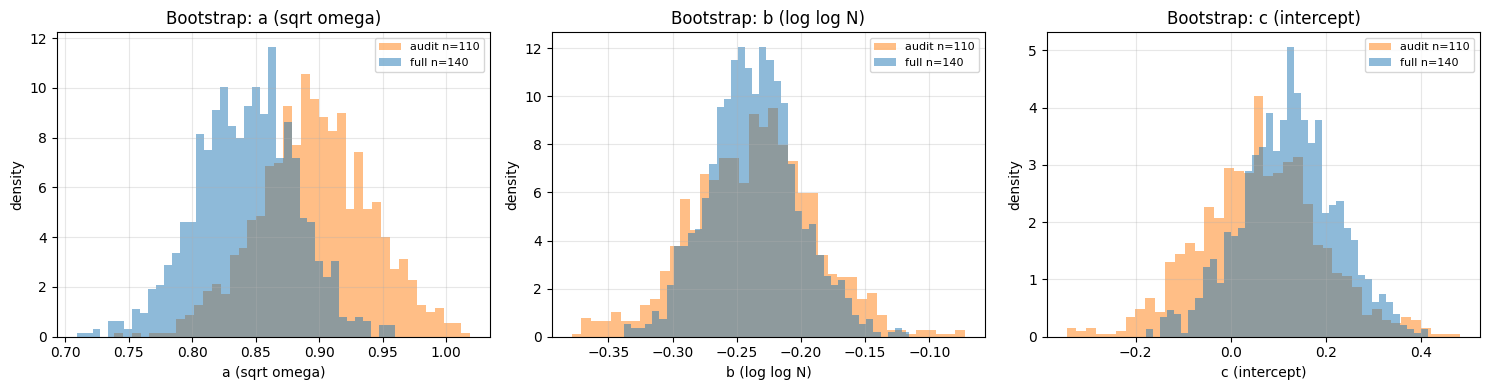

saved: fig9_extended_bootstrap.png


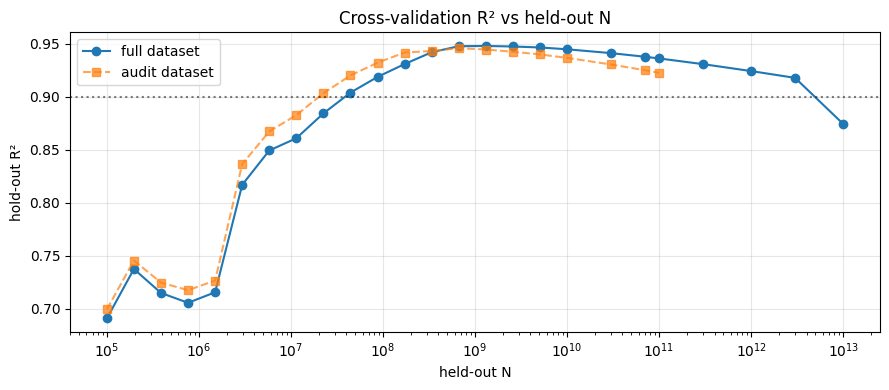

saved: fig10_r2_trajectory.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, lab) in enumerate(zip(axes, labels)):
    ax.hist(boot_a[:, i], bins=40, alpha=0.5, color='tab:orange',
            label=f'audit n={len(D_audit)}', density=True)
    ax.hist(boot_f[:, i], bins=40, alpha=0.5, color='tab:blue',
            label=f'full n={len(D_full)}', density=True)
    ax.set_xlabel(lab); ax.set_ylabel('density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_title(f'Bootstrap: {lab}')
plt.tight_layout()
plt.savefig('fig9_extended_bootstrap.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig9_extended_bootstrap.png')

# R²_CV trajectory
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cv['N'], cv['R2_full'], 'o-', color='tab:blue', label='full dataset')
if cv['R2_audit'].notna().any():
    cv2 = cv.dropna(subset=['R2_audit'])
    ax.plot(cv2['N'], cv2['R2_audit'], 's--', color='tab:orange', alpha=0.7, label='audit dataset')
ax.set_xscale('log'); ax.set_xlabel('held-out N'); ax.set_ylabel('hold-out R²')
ax.axhline(0.9, color='k', ls=':', alpha=0.5)
ax.grid(alpha=0.3); ax.legend()
ax.set_title('Cross-validation R² vs held-out N')
plt.tight_layout()
plt.savefig('fig10_r2_trajectory.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig10_r2_trajectory.png')

## 7. Paper update summary

After running this notebook, the following numbers in the paper may need updating (section 4.3 — bootstrap CI; section 4.2 — $M_1$ coefficients; table 1 — model comparison; section 4.4 — $\Delta$AIC). Read them off above:

- **$M_1$ coefficients on full dataset**: see section 3, row "M1" of the extended-range table.
- **90% CI on full dataset**: see section 5.
- **median $R^2_{CV}$**: see section 4.
- **$\Delta\mathrm{AIC}(M_1 - M_2)$**: see section 3, last line of the extended-range block.

If all of these shift by less than their audit-CI width, the original paper numbers are safe to keep; otherwise, update with the extended values. Either way, report that the dataset range is $N \in [10^5, 10^{12}]$ in the revised paper.